# Text Analysis and Natural Language Processing

Paul E. Anderson

In order for any of our previous methods to work on textual data, we must convert natural language fragments, paragraphs, sentences, books, blogs, etc into numeric data. We will introduce several methods to do this and apply them to real data. I have a soft spot for an older dating site called OK Cupid. I met my wife on OK cupid :)

In [ ]:
import pandas as pd
df = pd.read_csv(f'https://raw.githubusercontent.com/Anderson-Lab/csc-466-student/refs/heads/main/data/okcupid.csv')
df.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,height,status
0,31,NaN,mostly vegetarian,socially,sometimes,graduated from college/university,"75% nice, 45% shy, 80% stubborn, 100% charming...",i'm a new nurse. it rules.,"multiple-choice questions, dancing.",it depends on the people.,...,"san francisco, california",might want kids,gay,likes cats,buddhism,f,taurus and it&rsquo;s fun to think about,no,67.0,single
1,25,average,NaN,socially,NaN,working on college/university,"i like trees, spending long periods of time co...","studying landscape horticulture, beekeeping, g...","wasting time, making breakfast, nesting",i have a lot of freckles,...,"oakland, california",NaN,gay,NaN,NaN,m,sagittarius and it&rsquo;s fun to think about,no,66.0,single
2,43,curvy,NaN,rarely,never,graduated from masters program,NaN,NaN,NaN,NaN,...,"san francisco, california",has a kid,straight,likes dogs and has cats,other and laughing about it,f,leo and it&rsquo;s fun to think about,trying to quit,65.0,single
3,31,average,NaN,socially,never,NaN,"i am a seeker of laughs ,music ,magick good pe...",i strive to live life to the fullest and to tr...,i am good at my magic and weaving a world of i...,i am guessing y'all would notice my jewelry an...,...,"san francisco, california",doesn&rsquo;t want kids,gay,NaN,other and very serious about it,m,capricorn and it&rsquo;s fun to think about,trying to quit,70.0,single
4,34,NaN,NaN,socially,NaN,graduated from ph.d program,i've just moved here from london after finishi...,i'm doing a postdoc in psychology at stanford,NaN,NaN,...,"san francisco, california",NaN,gay,NaN,NaN,m,cancer but it doesn&rsquo;t matter,NaN,71.0,single


Some text data is categorical, and therefore, processing it is relatively straightforward.

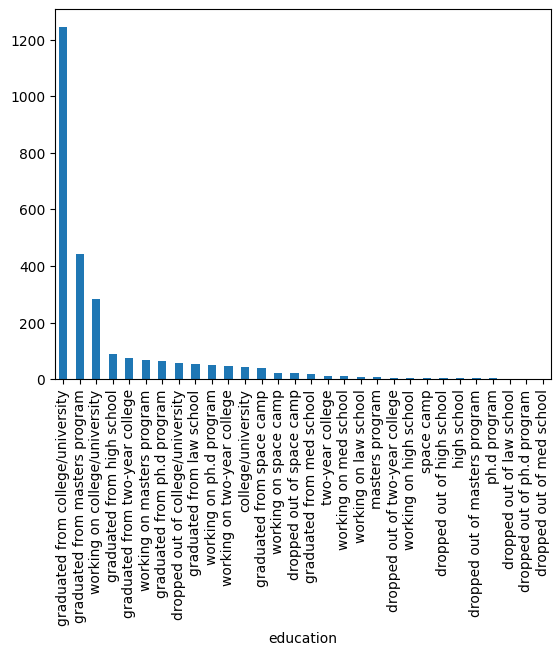

In [ ]:
df['education'].value_counts().plot.bar();

But what about the essay?

In [ ]:
text = df['essay9'].fillna("").str.replace('<[^<]+?>', '')

In [ ]:
text

,essay9
0,if you're butch that is great. also interested...
1,have interesting stories about life
2,
3,you are interested in meeting the strangest qu...
4,
...,...
2995,you can woo a man with your vocabulary.
2996,
2997,
2998,you've got the know-how and the elbow grease t...


How might you we make a recommendation based on the essay?

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(text.fillna("").head())
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 48 stored elements and shape (5, 40)>

Well that is not helpful! Notice that CountVectorizer returns the term-frequency matrix, not as a DataFrame or even as a numpy array, but as a scipy sparse matrix. A sparse matrix is one whose entries are mostly zeroes. Instead of storing individual values, we can simply store the locations of the non-zero entries and their values. This representation offers substantial memory savings because most of the elements are zero and thus not stored.

But what if you want to look at a subset of the data? How do we convert a sparse matrix to dense and label it? Careful doing this on a large dataset.

In [ ]:
Xdense = pd.DataFrame(X.todense(),columns=vectorizer.get_feature_names_out())
Xdense

,about,also,and,are,butch,down,drink,femmes,for,francisco,...,strangest,that,the,to,trans,treat,up,walk,want,you
0,0,2,0,0,1,0,1,1,1,0,...,0,1,0,1,1,1,0,1,1,2
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,2,0,1,1,0,1,1,...,1,0,1,0,0,0,1,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


This is a tabular representation of what is called a bag of words. A bag of words reduces a document to the multiset of its words, ignoring grammar and word order. (A multiset is like a set, except that elements are allowed to appear more than once.)

So, for example, the bag of words representation of "I am Sam. Sam I am." (the first two lines of Green Eggs and Ham) would be {I, I, am, am, Sam, Sam}. In Python, an easy way to represent multisets is with dictionaries, where the keys are the (unique) words and the values are the counts. So we would represent the above bag of words as {"I": 2, "am": 2, "Sam": 2}. However, such a representation is not conducive to recommendations.

**Stop and think:** What word appears most often?

In [ ]:
# Your solution here
sums.sort_values(ascending=False).head(30)

,0
you,5992
br,3744
to,3422
and,2998
the,1693
if,1426
are,1371
of,1216
or,1161
in,1110


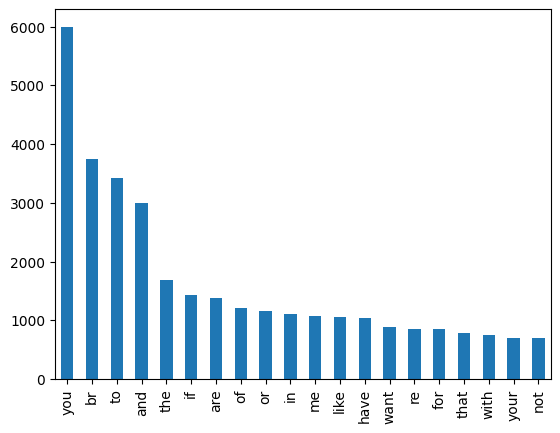

In [ ]:
sums.sort_values(ascending=False).iloc[:20].plot.bar();

**Stop and think:** Is the fact that _and_ is the most common word interesting?

###### Your solution here

### TF-IDF: Term frequency inverse document frequency
The problem with term frequencies (TF) is that common words like "the" and "that" tend to have high counts and dominate.

A better indicator of whether two documents are similar is if they share rare words.

In TF-IDF we take term frequency and re-weight each term by how many documents that term appears in (i.e., the document frequency).

We want words that appear in fewer documents to get more weight, so we take the inverse document frequency (IDF).

We take the logarithm of IDF because the distribution of IDFs is heavily skewed to the right. So in the end, the formula for IDF is:

$$ \textrm{idf}(t, D) = \log \frac{\text{# of documents}}{\text{# of documents containing $t$}} = \log \frac{|D|}{|d \in D: t \in d|}. $$
(Sometimes, $1$ will be added to the denominator to prevent division by zero, if there are terms in the vocabulary that do not appear in the corpus.)

To calculate TF-IDF, we simply multiply the term frequencies by the inverse document frequencies:

$$ \textrm{tf-idf}(d, t, D) = \textrm{tf}(d, t) \cdot \textrm{idf}(t, D). $$
Notice that unlike TF, the TF-IDF representation of a given document depends on the entire corpus of documents.


tf(d,t) -> term frequency of a term in a document

idf(t,D) -> weight of the term in a set of documents, the fewer the documents has the word, the more weight it has.

**Stop and think:** Let's see how our new vectorization changes are word ranking:

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Your solution here
pd.Series(vec.idf_,index=vec.get_feature_names_out()).sort_values()

,0
like,2.376017
br,2.420529
want,2.487554
know,3.030350
think,3.244649
...,...
04,8.313554
03,8.313554
zones,8.313554
zqgfxdsqft4,8.313554


**Stop and think:** Should we use the cosine similarity or Euclidean distance metrics?

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sims = pd.DataFrame(cosine_similarity(tf_idf_sparse))
sims

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,1.000000,0.0,0.0,0.127425,0.0,0.029144,0.051859,0.000000,0.039697,0.034801,...,0.028297,0.0,0.0,0.119946,0.0,0.000000,0.0,0.0,0.000000,0.0
1,0.000000,1.0,0.0,0.000000,0.0,0.000000,0.369017,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
2,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
3,0.127425,0.0,0.0,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
4,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,1.000000,0.0,0.0,0.047266,0.0
2996,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
2997,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
2998,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.041460,0.000000,0.258571,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.047266,0.0,0.0,1.000000,0.0


In [ ]:
import numpy as np
sims.values[np.tril_indices(len(sims))] = np.nan
sims

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,NaN,0.0,0.0,0.127425,0.0,0.029144,0.051859,0.0,0.039697,0.034801,...,0.028297,0.0,0.0,0.119946,0.0,0.0,0.0,0.0,0.000000,0.0
1,NaN,NaN,0.0,0.000000,0.0,0.000000,0.369017,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
2,NaN,NaN,NaN,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
3,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
4,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.047266,0.0
2996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000,0.0
2997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0
2998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [ ]:
sims.stack().sort_values(ascending=False)

395   1253    1.0
1903  2184    1.0
214   1191    1.0
1625  1670    1.0
35    2351    1.0
             ... 
685   2618    0.0
      2616    0.0
      2615    0.0
      2614    0.0
      2600    0.0
Length: 4498500, dtype: float64

In [ ]:
top_ix = sims.stack().sort_values(ascending=False).index[0]

In [ ]:
top_ix

(395, 1253)

In [ ]:
df.loc[list(top_ix)]

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,height,status
395,53,athletic,mostly anything,not at all,never,working on ph.d program,i have a full and busy life. i'm a happy campe...,i've been in my profession for a couple decade...,i'm good at my job; i'm a relatively good drum...,"i'm 6' 2"" and built like a football player -- ...",...,"oakland, california","doesn&rsquo;t have kids, and doesn&rsquo;t wan...",straight,likes dogs,other and very serious about it,m,cancer but it doesn&rsquo;t matter,no,74.0,single
1253,38,fit,anything,socially,never,graduated from masters program,i'm a big-picture person for the most part.,"i try to do something meaningful everyday, but...",taking it easy and being optimistic.,NaN,...,"palo alto, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,NaN,m,NaN,no,71.0,single


In [ ]:
list(text.loc[list(top_ix)])

["you'd like to chat", "you'd like to chat."]

**Stop and think:** Let's go a little farther down the list and see what other similar essays you can find.

In [ ]:
# Your solution here

**Stop and think:** Convert the self-summary variable (essay0) in the OKCupid data set to a TF-IDF representation. Use this to find a match for user 61 based on what he says he is looking for in a partner (essay9).